In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv("train.csv")
df.head()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [10]:
df1=df[df['TARGET']==1]
df0=df[df['TARGET']==0]

In [11]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_curve, roc_auc_score

In [12]:
X,y= make_classification(n_samples=200, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
model=DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.90      0.83      0.86        23
           1       0.79      0.88      0.83        17

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.86      0.85      0.85        40



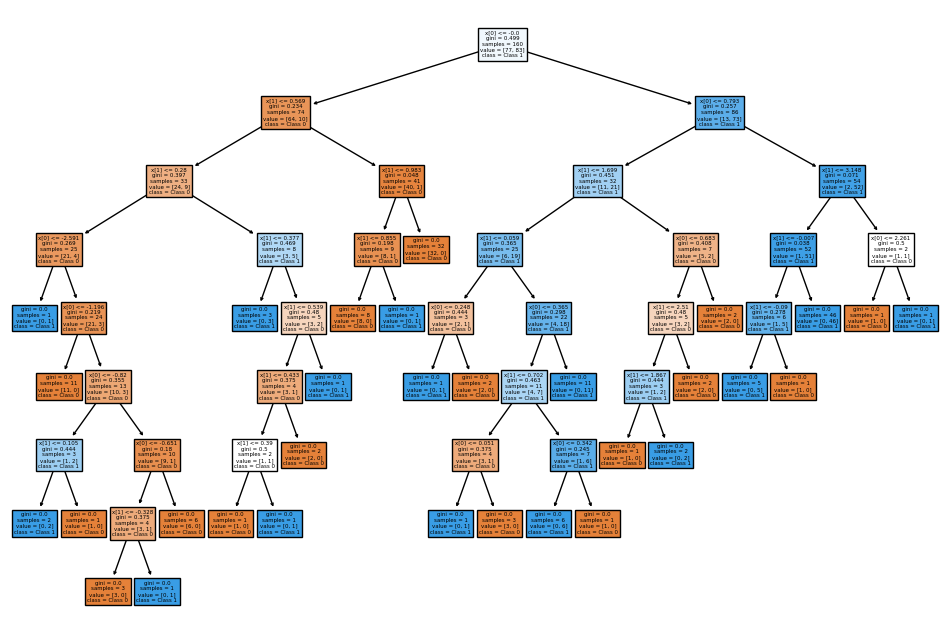

In [13]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model, filled=True, class_names=["Class 0","Class 1"])
plt.show()

In [14]:
y_probs=model.predict_proba(X_test)[:,1]

AUC Score: 0.8542199488491048


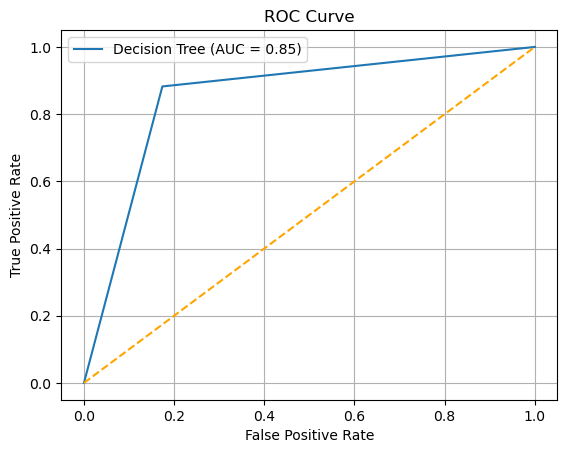

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)
print("AUC Score:", auc_score)

plt.figure()
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='orange')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
import tensorflow as tf

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import models, layers, regularizers

In [ ]:
def remove_label(df, label):
    x = df.drop(label, axis=1)
    y = df[label].copy()
    return (x, y)

In [ ]:
x_data, y_data = remove_label(df, "TARGET")
min_max = MinMaxScaler()
train_data_norm = pd.DataFrame(min_max.fit_transform(x_data), index=x_data.index, columns=x_data.columns)
train_data_norm['TARGET'] = y_data
train_data_norm

In [ ]:
train_set, val_set = train_test_split(train_data_norm, test_size=0.3, random_state=42, shuffle=True, stratify=None)
val_set, test_set = train_test_split(val_set, test_size=0.5, random_state=42, shuffle=True, stratify=None)

In [ ]:
x_train, y_train = remove_label(train_set, "TARGET")
x_val, y_val = remove_label(val_set, "TARGET")
x_test, y_test = remove_label(test_set, "TARGET")

In [ ]:
model = models.Sequential()

model.add(layers.Input((x_train.shape[1],)))
model.add(layers.Dense(100, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(layers.Dense(50, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(layers.Dense(25, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['AUC'])